In [108]:
import numpy as np
from scipy.optimize import curve_fit
import pandas as pd
import matplotlib.pyplot as plt

def fit_func(freq, tau, phi_0):
    omega = 2*np.pi*freq
    phi = np.arctan(omega*tau)
    return phi + phi_0

def temperature_dependence(T, t0, a, offset):
    return t0*np.exp(a*(T-298))+offset

plt.rcParams.update({
    "font.size": 14,        # default text size
    "axes.titlesize": 16,   # title size
    "axes.labelsize": 15,   # axis labels
    "legend.fontsize": 11,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

plt.rcParams.update({
    "font.family": "Times New Roman",  # Use Times New Roman for all text
    "mathtext.fontset": "custom",      # Use custom font for math
    "mathtext.rm": "Times New Roman",  # Roman font in math
    "mathtext.it": "Times New Roman:italic",  # Italic font in math
    "mathtext.bf": "Times New Roman:bold",    # Bold font in math
    "text.usetex": False
})

csv = "Amplitude_Data.csv"
df_amplitude = pd.read_csv(csv)

temp_amp = df_amplitude["Temperatures"]
life_amp = df_amplitude["Lifetimes"]
life_err_amp = df_amplitude["Errors"]
pop_amp = [df_amplitude["t0"][0], df_amplitude["a"][1], 0]
err_amp = [df_amplitude["t0_err"][0], df_amplitude["a_err"][0], 0]

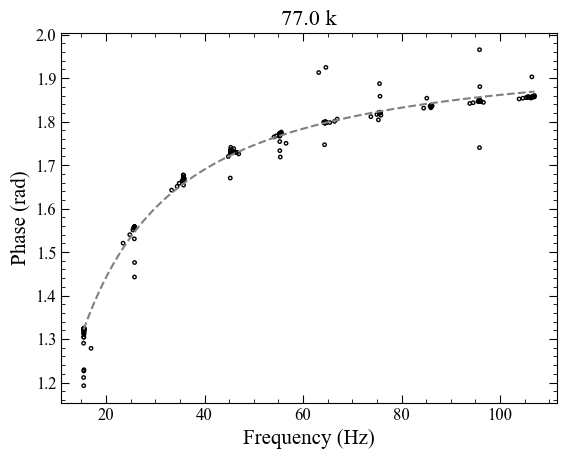

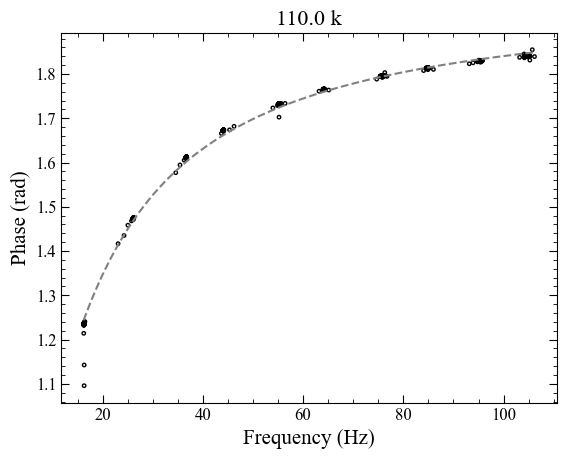

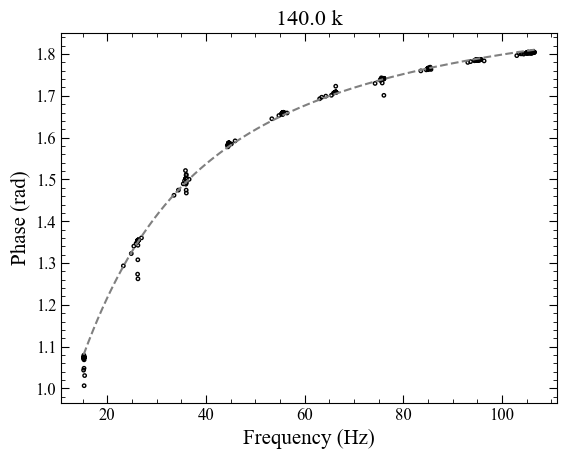

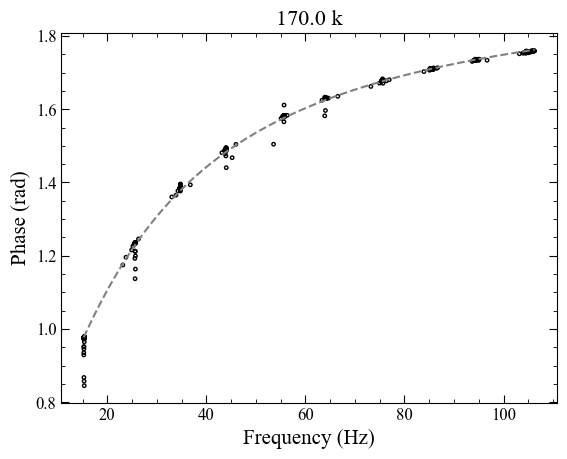

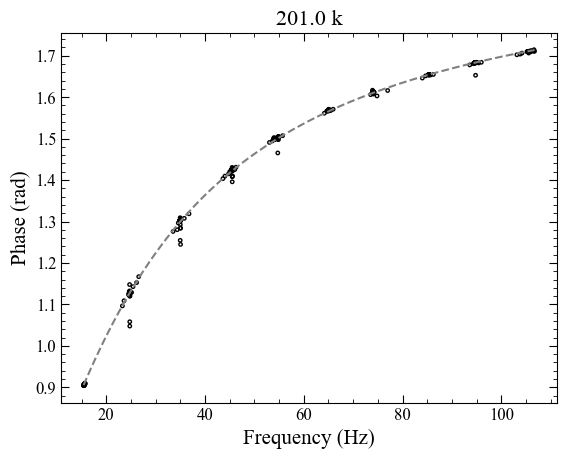

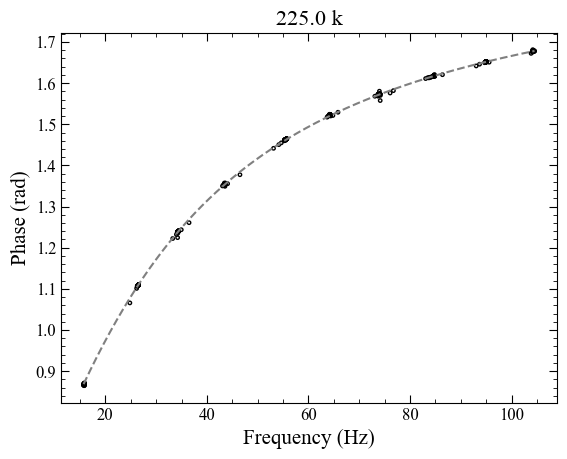

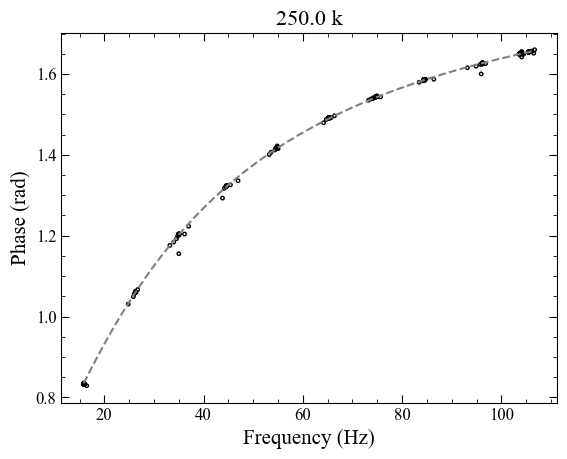

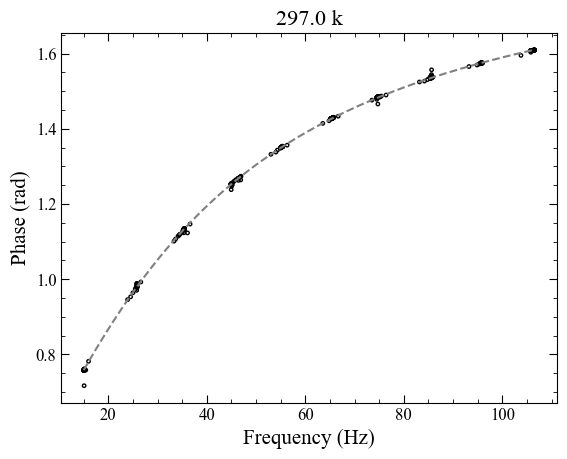

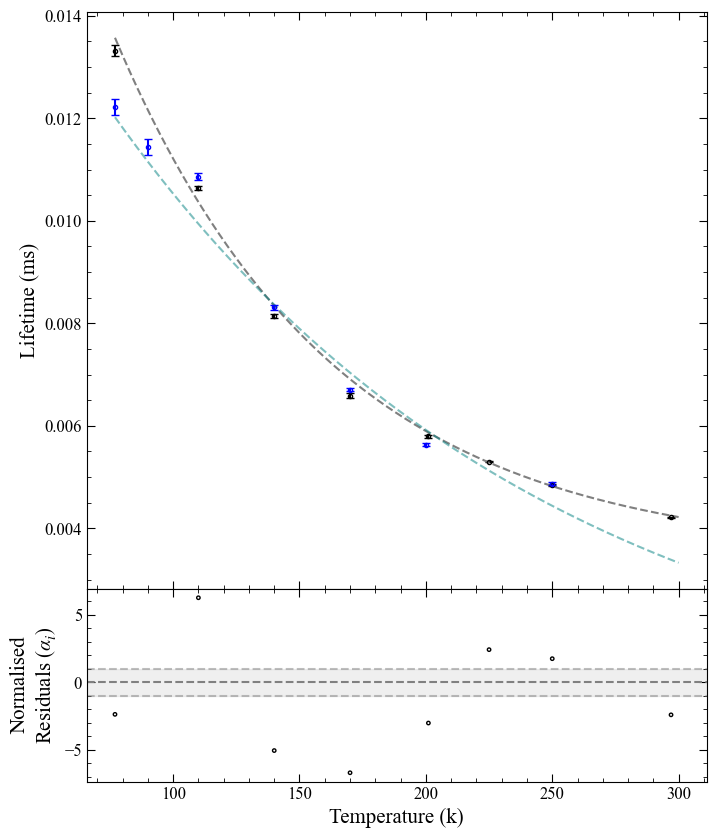

Phase Method lifetime: 0.00079 pm 0.00002
Amplitude Method lifetime: 0.00337 pm 0.00002


In [109]:
file = "Freq_Data.xlsx"

column_names = [
    ["freq_77", "phase_77"],
    ["freq_110", "phase_110"],
    ["freq_140", "phase_140"],
    ["freq_170", "phase_170"],
    ["freq_201", "phase_201"],
    ["freq_225", "phase_225"],
    ["freq_250", "phase_250"],
    ["freq_297", "phase_297"],
]

df = pd.read_excel(file)

points = [15, 25, 35, 45, 55, 65, 75, 85, 95, 105]
pm = 2

lifetimes = []
lifetime_errors = []
temperatures = []

for col in column_names:
    temp = float(col[0].split("_")[1])

    x_raw = df[col[0]]
    y_raw = df[col[1]]
    y_rad = y_raw * np.pi / 180

    mask = np.zeros_like(x_raw, dtype=bool)

    for p in points:
        mask |= (x_raw >= p - pm) & (x_raw <= p + pm)

    x_sliced = x_raw[mask]
    y_sliced = y_rad[mask]
    y_sliced = np.abs(y_sliced)

    p0 = [0.004,0.4]

    pop, cov = curve_fit(fit_func,
                         x_sliced,
                         y_sliced,
                         p0 = p0,
                         maxfev = 10000)

    x_fit = np.linspace(x_sliced.min(), x_sliced.max(), 10000)

    plt.figure(1)
    plt.scatter(x_sliced, y_sliced,
                marker = 'o', facecolor = 'none',color = "black", s = 6)
    plt.plot(x_fit, fit_func(x_fit, *pop),
             color = "grey", linestyle = "--")

    plt.minorticks_on()
    plt.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    plt.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

    plt.title(f"{temp} k")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Phase (rad)")
    plt.show()

    temperatures.append(temp)
    lifetimes.append(pop[0])
    lifetime_errors.append(np.sqrt(np.diag(cov)[0]))


temperatures = np.array(temperatures)
lifetimes = np.array(lifetimes)
lifetime_errors = np.array(lifetime_errors)

T_fit = np.linspace(temperatures.min(), 300, 10000)

p0 = [0.003, #roomtemp lifetime
      -0.01, #a
      0.001] #offset

p0_bounds = [
    [0, -np.inf, 0.0001], #lower
    [np.inf, 0, np.inf] #upper
]

pop, cov = curve_fit(temperature_dependence,
                     temperatures,
                     lifetimes,
                     sigma = lifetime_errors,
                     absolute_sigma = True,
                     p0 = p0,
                     bounds = p0_bounds,
                     maxfev = 10000)

residuals = (lifetimes-temperature_dependence(temperatures, *pop))/lifetime_errors


fig = plt.figure(figsize = (8,10))

gs = fig.add_gridspec(
    2, 1,
    hspace = 0,
    height_ratios = [3,1],
)
ax_main = fig.add_subplot(gs[0])
ax_res = fig.add_subplot(gs[1], sharex = ax_main)

###########
# main plot
###########

ax_main.set_ylabel("Lifetime (ms)")

ax_main.errorbar(temperatures, lifetimes, yerr= lifetime_errors,
            marker = 'o', markerfacecolor = 'none',color = "black", markersize = 3, capsize = 3, linestyle = "none")
ax_main.plot(T_fit, temperature_dependence(T_fit, *pop),
          color = "grey", linestyle = "--")

ax_main.errorbar(temp_amp, life_amp, yerr= life_err_amp,
            marker = 'o', markerfacecolor = 'none',color = "blue", markersize = 3, capsize = 3, linestyle = "none")
ax_main.plot(T_fit, temperature_dependence(T_fit, *pop_amp),
          color = "teal", linestyle = "--", alpha = 0.5)

###############
# residual plot
###############


ax_res.set_xlabel("Temperature (k)")
ax_res.set_ylabel("Normalised\nResiduals ($\\alpha_i$)")

ax_res.scatter(temperatures, residuals,
            marker = 'o', facecolor = 'none',color = "black", s = 6)

ax_res.axhspan(-1,1, color = "grey", alpha = 0.12)
ax_res.axhline(-1, color = "grey", linestyle = "--",alpha = 0.5)
ax_res.axhline(1, color = "grey", linestyle = "--", alpha = 0.5)
ax_res.axhline(0, color = "grey", linestyle = "--")

for ax in [ax_main, ax_res]:
    ax.minorticks_on()
    ax.tick_params(which='major', size=6, direction='in',
                   right=True, top=True)
    ax.tick_params(which='minor', size=3, direction='in',
                   right=True, top=True)

plt.show()

print(f"Phase Method lifetime: {pop[0]:.5f} pm {np.sqrt(np.diag(cov)[0]):.5f}")
print(f"Amplitude Method lifetime: {pop_amp[0]:.5f} pm {err_amp[0]:.5f}")